In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anas245","key":"33427fa23ffd0c98276ff81b2a6ad1ce"}'}

In [ ]:
import os

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ryanmouton/ohiot1dm

Dataset URL: https://www.kaggle.com/datasets/ryanmouton/ohiot1dm
License(s): MIT
  0% 0.00/2.22M [00:00<?, ?B/s]
100% 2.22M/2.22M [00:00<00:00, 382MB/s]


In [ ]:
!unzip ohiot1dm.zip

Archive:  ohiot1dm.zip
  inflating: 559-ws-testing.xml      
  inflating: 559-ws-training.xml     
  inflating: 563-ws-testing.xml      
  inflating: 563-ws-training.xml     
  inflating: 570-ws-testing.xml      
  inflating: 570-ws-training.xml     
  inflating: 575-ws-testing.xml      
  inflating: 575-ws-training.xml     
  inflating: 588-ws-testing.xml      
  inflating: 588-ws-training.xml     
  inflating: 591-ws-testing.xml      
  inflating: 591-ws-training.xml     


In [ ]:
import xml.etree.ElementTree as ET
import glob
import os

# If files are uploaded directly, they will be in current directory
xml_files = glob.glob("*.xml")

print(f"Found {len(xml_files)} XML files\n")

results = []

for file in xml_files:
    tree = ET.parse(file)
    root = tree.getroot()

    patient_id = root.attrib.get("id", "Unknown")

    glucose_values = []

    glucose_section = root.find("glucose_level")

    if glucose_section is not None:
        for event in glucose_section:
            value = int(event.attrib["value"])
            glucose_values.append(value)

    if len(glucose_values) > 0:
        min_val = min(glucose_values)
        max_val = max(glucose_values)

        print(f"Patient {patient_id}:")
        print(f"   Min Glucose = {min_val} mg/dL")
        print(f"   Max Glucose = {max_val} mg/dL\n")

        results.append((patient_id, min_val, max_val))
    else:
        print(f"Patient {patient_id}: No glucose data found\n")

Found 12 XML files

Patient 563:
   Min Glucose = 62 mg/dL
   Max Glucose = 313 mg/dL

Patient 588:
   Min Glucose = 66 mg/dL
   Max Glucose = 354 mg/dL

Patient 570:
   Min Glucose = 46 mg/dL
   Max Glucose = 377 mg/dL

Patient 570:
   Min Glucose = 60 mg/dL
   Max Glucose = 388 mg/dL

Patient 575:
   Min Glucose = 40 mg/dL
   Max Glucose = 342 mg/dL

Patient 559:
   Min Glucose = 45 mg/dL
   Max Glucose = 400 mg/dL

Patient 591:
   Min Glucose = 43 mg/dL
   Max Glucose = 291 mg/dL

Patient 588:
   Min Glucose = 40 mg/dL
   Max Glucose = 400 mg/dL

Patient 575:
   Min Glucose = 40 mg/dL
   Max Glucose = 400 mg/dL

Patient 591:
   Min Glucose = 40 mg/dL
   Max Glucose = 397 mg/dL

Patient 559:
   Min Glucose = 40 mg/dL
   Max Glucose = 400 mg/dL

Patient 563:
   Min Glucose = 40 mg/dL
   Max Glucose = 400 mg/dL



In [ ]:
import xml.etree.ElementTree as ET
import glob

xml_files = glob.glob("*.xml")

total_samples = 0
hypo_samples = 0

for file in xml_files:
    tree = ET.parse(file)
    root = tree.getroot()

    glucose_section = root.find("glucose_level")

    if glucose_section is not None:
        for event in glucose_section:
            value = int(event.attrib["value"])

            total_samples += 1

            if value < 70:
                hypo_samples += 1

print("===== DATASET STATISTICS =====")
print(f"Total Glucose Samples: {total_samples}")
print(f"Hypoglycemia Samples (<70 mg/dL): {hypo_samples}")

percentage = (hypo_samples / total_samples) * 100
print(f"Hypoglycemia Percentage: {percentage:.2f}%")

===== DATASET STATISTICS =====
Total Glucose Samples: 85225
Hypoglycemia Samples (<70 mg/dL): 2736
Hypoglycemia Percentage: 3.21%


In [ ]:
import xml.etree.ElementTree as ET
import glob
import numpy as np

WINDOW = 12      # 1 hour history
HORIZON = 6      # 30 min ahead

xml_files = glob.glob("*.xml")

all_series = []

# ---- Extract all glucose values ----
for file in xml_files:
    tree = ET.parse(file)
    root = tree.getroot()

    glucose_section = root.find("glucose_level")

    if glucose_section is not None:
        series = []
        for event in glucose_section:
            value = int(event.attrib["value"])
            series.append(value)

        all_series.append(series)

# ---- Create sliding windows ----
X = []
Y = []

for series in all_series:
    for i in range(WINDOW, len(series) - HORIZON):

        window = series[i-WINDOW:i]
        future_value = series[i+HORIZON]

        label = 1 if future_value < 70 else 0

        X.append(window)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Dataset shape:")
print("X:", X.shape)
print("Y:", Y.shape)
print("Hypo percentage:", np.mean(Y)*100)

Dataset shape:
X: (85009, 12)
Y: (85009,)
Hypo percentage: 3.218482748885412


In [ ]:
X = X / 400.0   # since max glucose ~400
X.shape

(85009, 12)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (68007, 12)
Test: (17002, 12)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0,1])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

print(class_weights)

{0: np.float64(0.5166291895833967), 1: np.float64(15.53380539058931)}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(12,1)),

    layers.Conv1D(8, kernel_size=3, padding='same'),
    layers.ReLU(),
    layers.MaxPooling1D(2),

    layers.Conv1D(16, kernel_size=3, padding='same'),
    layers.ReLU(),
    layers.GlobalAveragePooling1D(),

    layers.Dense(2)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 12, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 16)          │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 6, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466 (1.82 KB)

 Trainable params: 466 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train = X_train.reshape(-1,12,1)
X_test  = X_test.reshape(-1,12,1)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8911 - loss: 0.5858 - val_accuracy: 0.7092 - val_loss: 0.5206
Epoch 2/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7647 - loss: 0.4458 - val_accuracy: 0.7792 - val_loss: 0.4310
Epoch 3/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7759 - loss: 0.4442 - val_accuracy: 0.7754 - val_loss: 0.4548
Epoch 4/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7919 - loss: 0.4130 - val_accuracy: 0.7958 - val_loss: 0.4173
Epoch 5/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8063 - loss: 0.3905 - val_accuracy: 0.7901 - val_loss: 0.4232
Epoch 6/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8121 - loss: 0.3670 - val_accuracy: 0.8429 - val_loss: 0.3333
Epoch 7/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8253 - loss: 0.3434 - val_accuracy: 0.8418 - val_loss: 0.3447
Epoch 8/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8488 - loss: 0.3148 - val_accuracy: 0.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get probabilities
logits = model.predict(X_test)
probs = tf.nn.softmax(logits).numpy()

# Change threshold
threshold = 0.7   # try 0.6, 0.7, 0.8

y_pred = (probs[:,1] > threshold).astype(int)

print(classification_report(y_test, y_pred))

532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     16455
           1       0.26      0.79      0.39       547

    accuracy                           0.92     17002
   macro avg       0.62      0.86      0.67     17002
weighted avg       0.97      0.92      0.94     17002



In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_data_gen():
    for i in range(1000):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("INT8 model generated.")

Saved artifact at '/tmp/tmp3bg4xu0_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140386852616720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852617488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852617680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852618064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852616528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852617872: TensorSpec(shape=(), dtype=tf.resource, name=None)
INT8 model generated.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

# Load INT8 model
interpreter = tf.lite.Interpreter(model_path="model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get scale and zero-point
input_scale, input_zero = input_details[0]['quantization']
output_scale, output_zero = output_details[0]['quantization']

threshold = 0.7   # try 0.6, 0.7, 0.8

y_pred = []

for i in range(len(X_test)):

    x = X_test[i:i+1]
    x_int8 = (x / input_scale + input_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], x_int8)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    output_float = (output.astype(np.float32) - output_zero) * output_scale

    # Softmax
    probs = tf.nn.softmax(output_float).numpy()

    pred = 1 if probs[0][1] > threshold else 0
    y_pred.append(pred)

y_pred = np.array(y_pred)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


              precision    recall  f1-score   support

           0       0.99      0.93      0.96     16455
           1       0.26      0.79      0.39       547

    accuracy                           0.92     17002
   macro avg       0.63      0.86      0.67     17002
weighted avg       0.97      0.92      0.94     17002



In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpho_t0qb6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140386852616720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852617488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852617680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852618064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852616528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140386852617872: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
import numpy as np
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="model_int8.tflite")
interpreter.allocate_tensors()

tensor_details = interpreter.get_tensor_details()
for tensor in interpreter.get_tensor_details():
    print(tensor["index"], tensor["name"], tensor["shape"])

for tensor in tensor_details:
    if "kernel" in tensor["name"] or "weight" in tensor["name"]:
        weights = interpreter.get_tensor(tensor["index"])
        print(tensor["name"], weights.shape)

0 serving_default_keras_tensor:0 [ 1 12  1]
1 arith.constant []
2 arith.constant1 [3]
3 arith.constant2 []
4 arith.constant3 [3]
5 arith.constant4 [3]
6 tfl.pseudo_qconst [2]
7 tfl.pseudo_qconst1 [ 2 16]
8 tfl.pseudo_qconst2 [16]
9 tfl.pseudo_qconst3 [16  1  3  8]
10 tfl.pseudo_qconst4 [8]
11 tfl.pseudo_qconst5 [8 1 3 1]
12 sequential_1/conv1d_1/convolution/ExpandDims [ 1  1 12  1]
13 sequential_1/re_lu_1/Relu;sequential_1/conv1d_1/BiasAdd;sequential_1/conv1d_1/convolution/Squeeze;;sequential_1/conv1d_1/convolution [ 1  1 12  8]
14 sequential_1/re_lu_1/Relu;sequential_1/conv1d_1/BiasAdd;sequential_1/conv1d_1/convolution/Squeeze; [ 1 12  8]
15 sequential_1/max_pooling1d_1/MaxPool1d/ExpandDims [ 1  1 12  8]
16 sequential_1/max_pooling1d_1/MaxPool1d [1 1 6 8]
17 sequential_1/max_pooling1d_1/MaxPool1d/Squeeze [1 6 8]
18 sequential_1/conv1d_1_2/convolution/ExpandDims [1 1 6 8]
19 sequential_1/re_lu_1_2/Relu;sequential_1/conv1d_1_2/BiasAdd;sequential_1/conv1d_1_2/convolution/Squeeze;;sequent

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
np.savetxt("conv1_weights.txt", weights.flatten(), fmt="%d")

In [ ]:
import numpy as np

def save_tensor(idx, name):
    tensor = interpreter.get_tensor(idx)
    print(name, tensor.shape)
    print("Min/Max:", tensor.min(), tensor.max())
    np.savetxt(name + ".mem", tensor.flatten(), fmt="%d")

save_tensor(11, "conv1_weights")
save_tensor(10, "conv1_bias")

save_tensor(9, "conv2_weights")
save_tensor(8, "conv2_bias")

save_tensor(7, "dense_weights")
save_tensor(6, "dense_bias")

conv1_weights (8, 1, 3, 1)
Min/Max: -127 127
conv1_bias (8,)
Min/Max: -7641 16499
conv2_weights (16, 1, 3, 8)
Min/Max: -127 127
conv2_bias (16,)
Min/Max: -2927 3273
dense_weights (2, 16)
Min/Max: -127 127
dense_bias (2,)
Min/Max: -668 752


In [ ]:
for tensor in interpreter.get_tensor_details():
    qp = tensor["quantization_parameters"]
    if len(qp["scales"]) > 0:
        print(tensor["name"])
        print("Scale:", qp["scales"])
        print("Zero Point:", qp["zero_points"])

serving_default_keras_tensor:0
Scale: [0.00392157]
Zero Point: [-128]
tfl.pseudo_qconst
Scale: [0.00019773 0.00017548]
Zero Point: [0 0]
tfl.pseudo_qconst1
Scale: [0.01628888 0.01445636]
Zero Point: [0 0]
tfl.pseudo_qconst2
Scale: [5.2549753e-05 6.9731163e-05 8.4522100e-05 2.2282975e-05 4.8049980e-05
 4.2569754e-05 7.7661825e-05 2.3409477e-05 5.3956064e-05 2.3187356e-05
 2.4654202e-05 8.9996771e-05 5.4025502e-05 7.1464427e-05 6.6882443e-05
 4.0274288e-05]
Zero Point: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
tfl.pseudo_qconst3
Scale: [0.00529877 0.00703122 0.00852264 0.00224687 0.00484504 0.00429245
 0.0078309  0.00236046 0.00544057 0.00233806 0.00248596 0.00907467
 0.00544757 0.00720599 0.00674398 0.00406099]
Zero Point: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
tfl.pseudo_qconst4
Scale: [1.29373375e-05 3.14821082e-05 1.39837102e-05 3.56826495e-05
 3.11201984e-05 5.15889587e-05 1.24740163e-05 1.09478233e-05]
Zero Point: [0 0 0 0 0 0 0 0]
tfl.pseudo_qconst5
Scale: [0.00329902 0.00802794 0.00356585 0.0

In [ ]:
import tensorflow as tf
import datetime

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True
)

In [ ]:
!pip install pydot graphviz

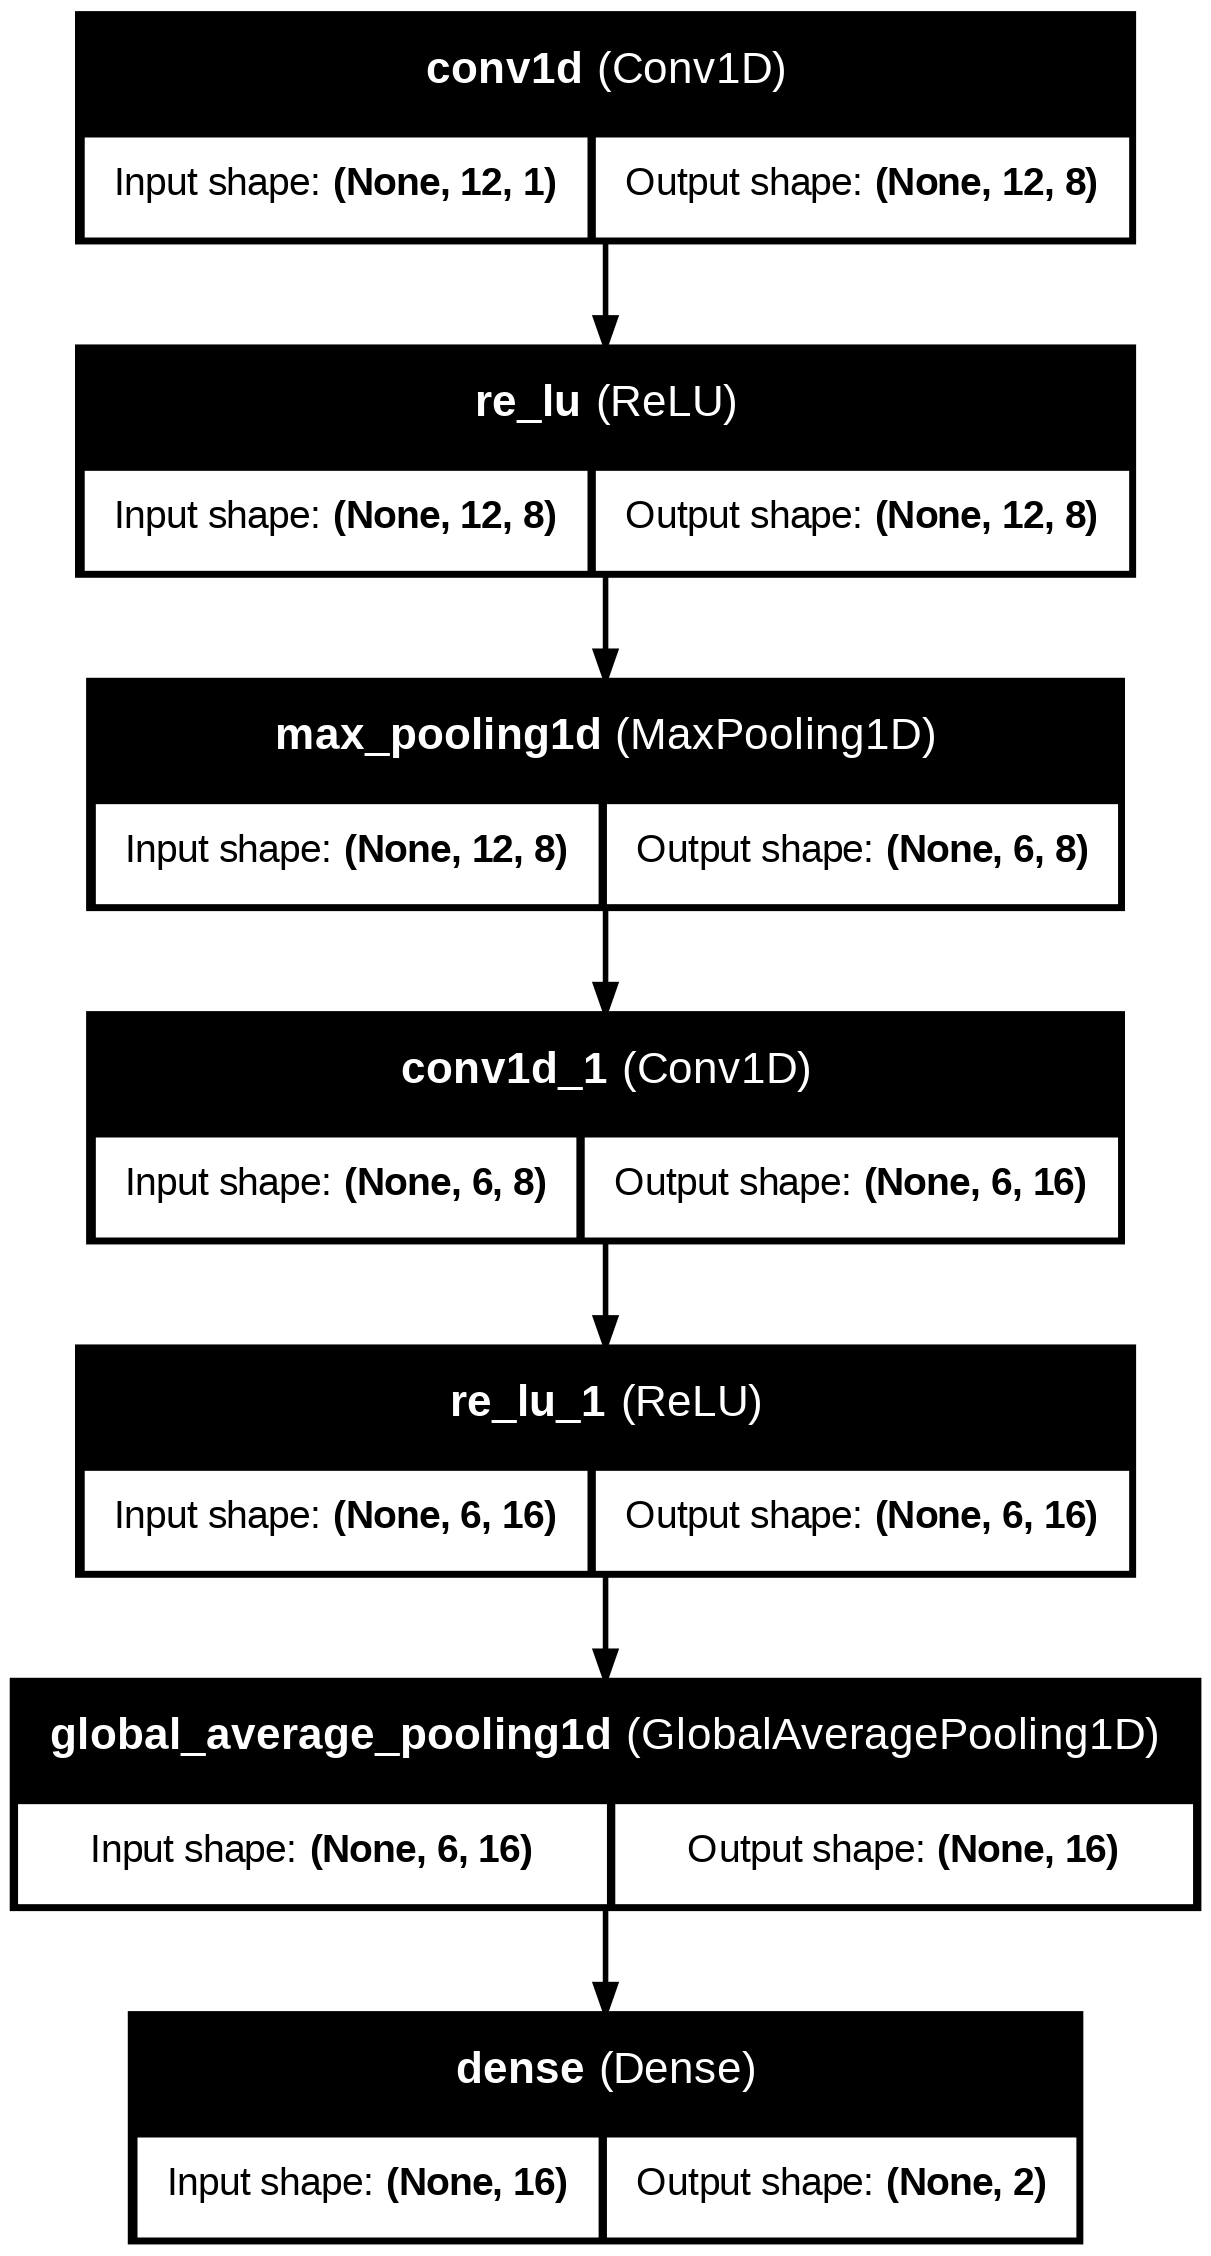

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='model.png',
           show_shapes=True,
           show_layer_names=True)

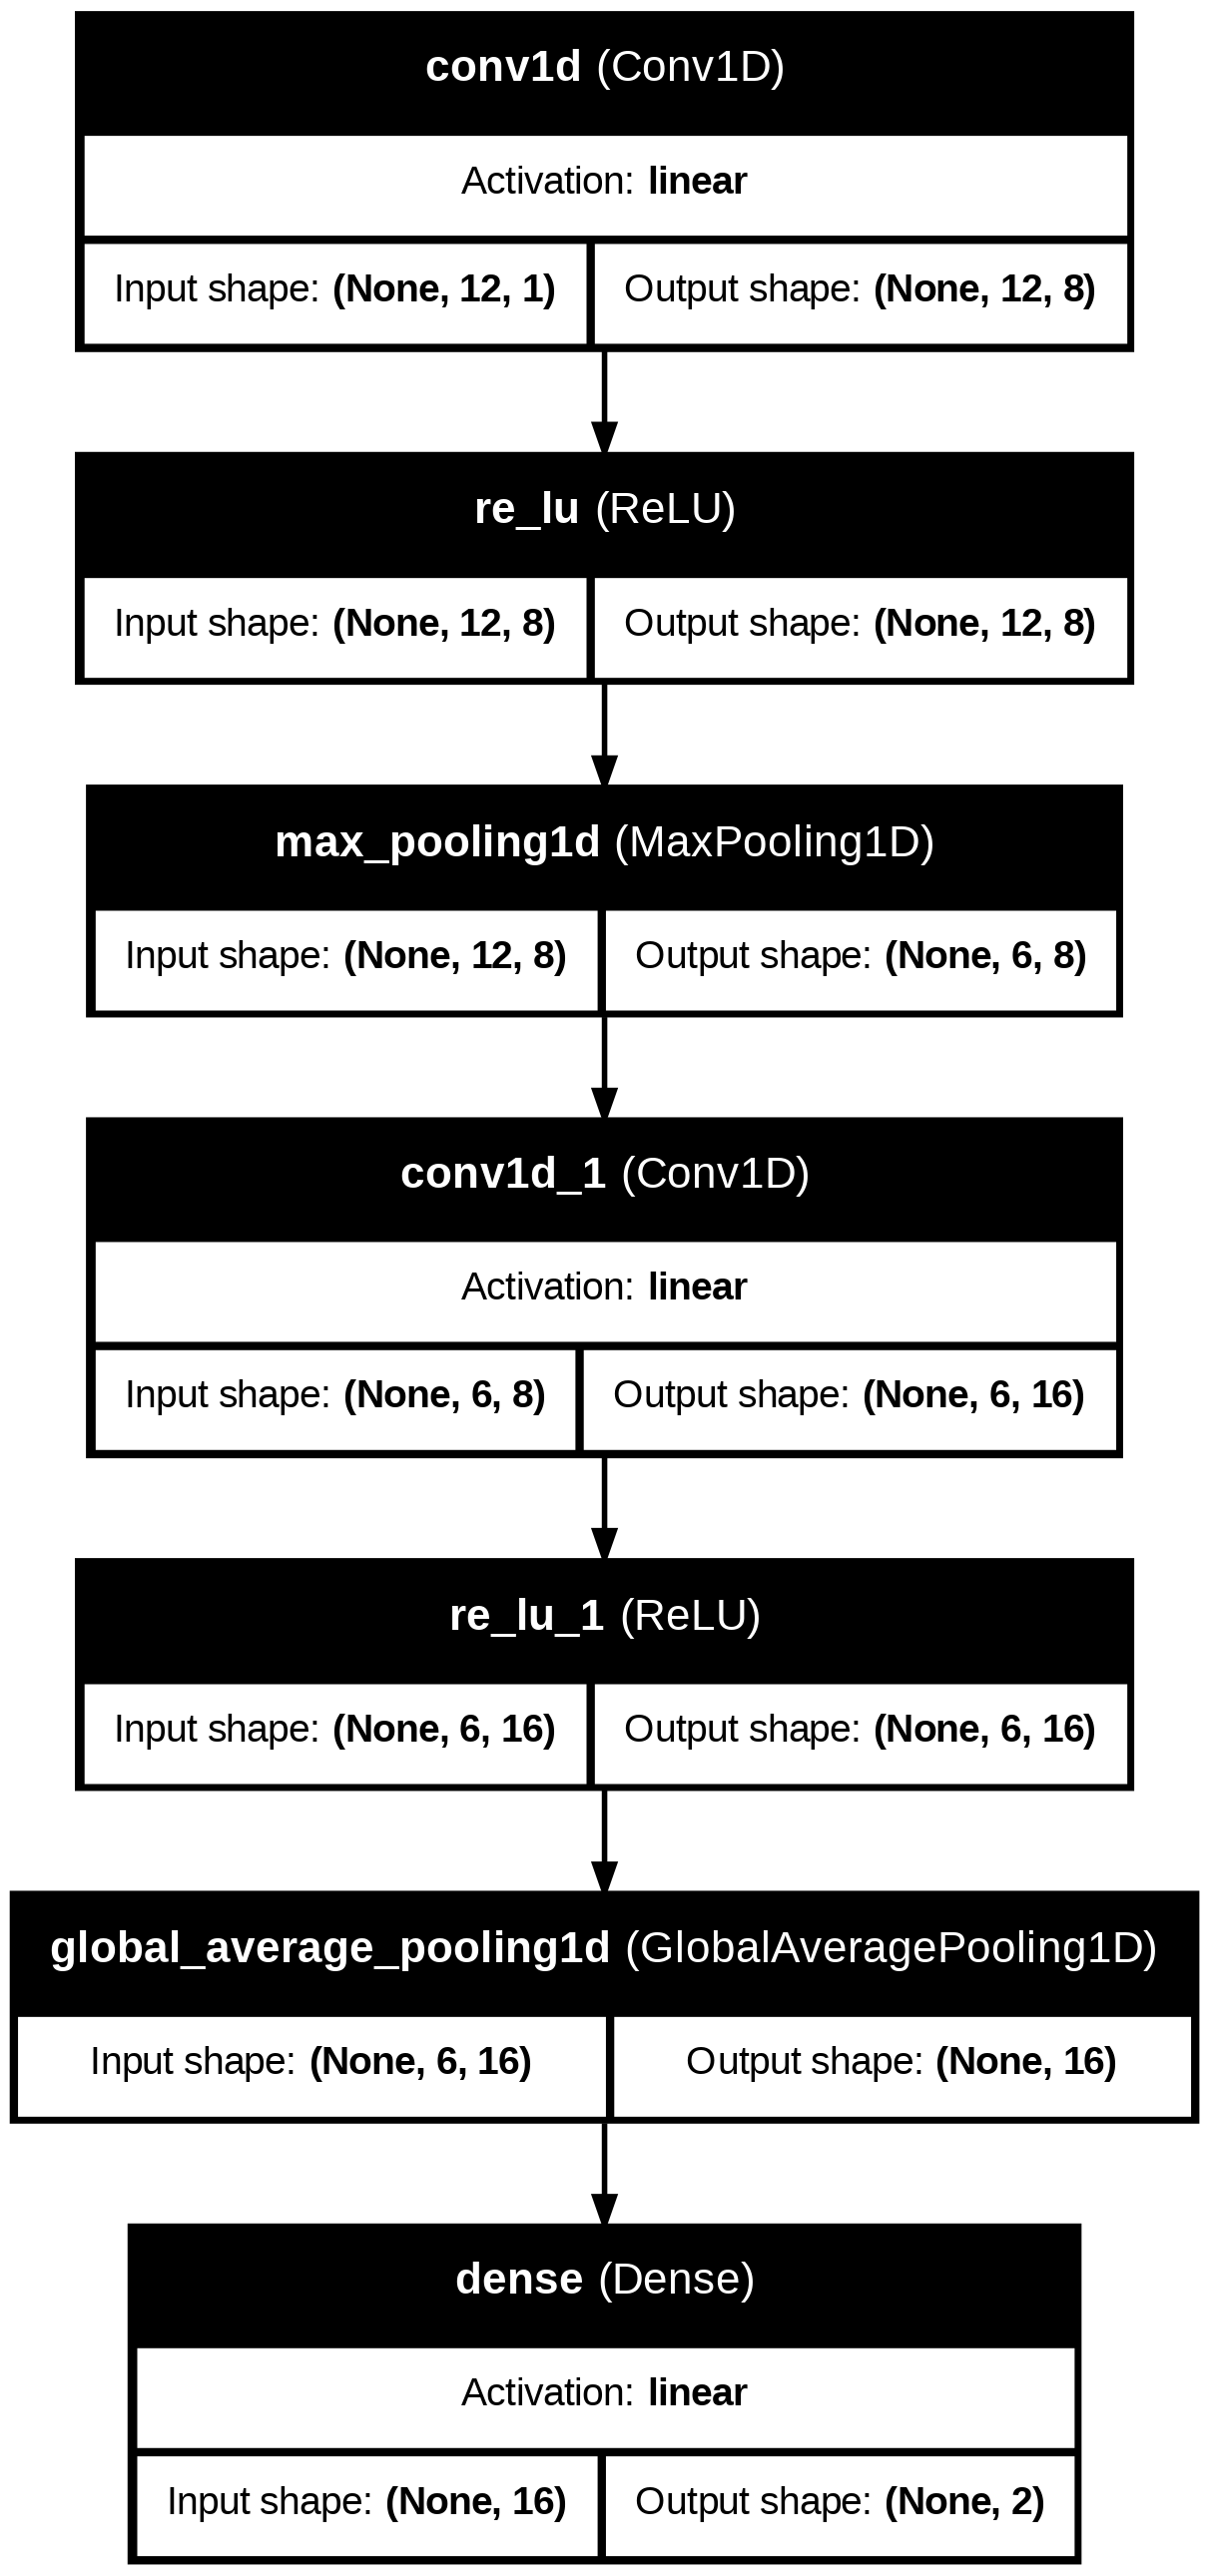

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="model_visual.png",
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    rankdir="TB",      # TB = top-bottom, LR = left-right
    dpi=200,           # higher resolution
    expand_nested=True
)

In [ ]:
pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.6 MB/s eta 0:00:00


In [ ]:
model.build(input_shape=(None, 12, 1))  # (batch, timesteps, channels)

In [ ]:
import visualkeras
from PIL import ImageFont



visualkeras.layered_view(
    model,
    legend=True,
    to_file="model_3d.png"
)

AttributeError: 'Conv1D' object has no attribute 'output_shape'